# DL054 预训练目标与数据构造

同一原创语料的AR/MLM数据构造与独立文档packing。先预测结果再运行；这个未训练探针检查结构，不比较语言能力。

In [1]:
from pathlib import Path
import sys,json,unittest
candidates=[Path.cwd(),Path.cwd()/"units"/"054"]
ROOT=next((p.resolve() for p in candidates if p.name=="054" and (p/"experiment.py").exists()),None)
if ROOT is None: raise RuntimeError("从054目录或课程根启动Notebook")
sys.path.insert(0,str(ROOT))
from experiment import *
from generate_data import VOCAB,corpus
setup();REPLAY=ROOT/"notebook_replay"
print("torch",torch.__version__,"CPU float64")

torch 2.7.1+cpu CPU float64


## 1 用词元名称检查预测对
A=[蓝,猫]，B=[红]。每个文档独立移位，然后拼接并重置位置。不要把IGNORE送入Embedding。

In [2]:
batch=ar_packed([[4,7],[5]])
for k in ["x","y","position","segment","allow"]: print(k,batch[k])
print("inputs",[VOCAB[i] for i in batch["x"][0]])
print("targets",[VOCAB[i] for i in batch["y"][0]])

x tensor([[1, 4, 7, 1, 5]])
y tensor([[4, 7, 2, 5, 2]])
position tensor([[0, 1, 2, 0, 1]])
segment tensor([0, 0, 0, 1, 1])
allow tensor([[[ True, False, False, False, False],
         [ True,  True, False, False, False],
         [ True,  True,  True, False, False],
         [False, False, False,  True, False],
         [False, False, False,  True,  True]]])
inputs ['<bos>', '蓝', '猫', '<bos>', '红']
targets ['蓝', '猫', '<eos>', '红', '<eos>']


## 2 手算概率 梯度与两个更新
只优化独立logits，隔离NLL归约。位置2无有效标签，不参加分母。

In [3]:
for row in nll_ledger():
    print(json.dumps(row,ensure_ascii=False,indent=2))

{
  "step": 0,
  "logits": [
    [
      [
        0.6931471805599453,
        0.0,
        0.0
      ],
      [
        0.0,
        1.0986122886681098,
        0.0
      ],
      [
        9.0,
        -4.0,
        1.0
      ]
    ]
  ],
  "probabilities": [
    [
      [
        0.5,
        0.25,
        0.25
      ],
      [
        0.2,
        0.6000000000000001,
        0.2
      ],
      [
        0.9996623910609799,
        2.259566299568127e-06,
        0.0003353493727206248
      ]
    ]
  ],
  "sum_nll": 1.203972804325936,
  "count": 2,
  "mean_nll": 0.601986402162968,
  "gradient": [
    [
      [
        -0.25,
        0.125,
        0.125
      ],
      [
        0.09999999999999999,
        -0.19999999999999996,
        0.09999999999999999
      ],
      [
        0.0,
        0.0,
        0.0
      ]
    ]
  ]
}
{
  "step": 1,
  "logits": [
    [
      [
        0.7431471805599453,
        -0.025,
        -0.025
      ],
      [
        -0.02,
        1.1386122886681

## 3 两种目标和packing干预
run重新生成相同语料、构造全部数组、执行两层未训练Transformer，并保留错误标签/位置/跨文档对照。

In [4]:
results=run(REPLAY)
print("AR vs MLM有效数",results["ar"]["count"],results["mlm"]["count"])
print("注意：两个平均NLL不是目标优劣排名")

{
  "hand_nll": [
    {
      "step": 0,
      "logits": [
        [
          [
            0.6931471805599453,
            0.0,
            0.0
          ],
          [
            0.0,
            1.0986122886681098,
            0.0
          ],
          [
            9.0,
            -4.0,
            1.0
          ]
        ]
      ],
      "probabilities": [
        [
          [
            0.5,
            0.25,
            0.25
          ],
          [
            0.2,
            0.6000000000000001,
            0.2
          ],
          [
            0.9996623910609799,
            2.259566299568127e-06,
            0.0003353493727206248
          ]
        ]
      ],
      "sum_nll": 1.203972804325936,
      "count": 2,
      "mean_nll": 0.601986402162968,
      "gradient": [
        [
          [
            -0.25,
            0.125,
            0.125
          ],
          [
            0.09999999999999999,
            -0.19999999999999996,
            0.0999999999999999

## 4 全部独立测试
含解析梯度、全参数packing等价、忽略输出仍能提供上下文梯度、去重、边界与失败对照。

In [5]:
from test_experiment import Tests
outcome=unittest.TextTestRunner(verbosity=2).run(unittest.defaultTestLoader.loadTestsFromTestCase(Tests))
if not outcome.wasSuccessful(): raise RuntimeError("DL054 tests failed")

test_data_split (test_experiment.Tests.test_data_split) ... 

ok


test_ignored_context_can_receive_gradient (test_experiment.Tests.test_ignored_context_can_receive_gradient) ... 

ok


test_loss_and_gradient (test_experiment.Tests.test_loss_and_gradient) ... 

...

ok


test_shift_boundary (test_experiment.Tests.test_shift_boundary) ... 

ok


----------------------------------------------------------------------
Ran 7 tests in 0.036s

OK


{
  "hand_nll": [
    {
      "step": 0,
      "logits": [
        [
          [
            0.6931471805599453,
            0.0,
            0.0
          ],
          [
            0.0,
            1.0986122886681098,
            0.0
          ],
          [
            9.0,
            -4.0,
            1.0
          ]
        ]
      ],
      "probabilities": [
        [
          [
            0.5,
            0.25,
            0.25
          ],
          [
            0.2,
            0.6000000000000001,
            0.2
          ],
          [
            0.9996623910609799,
            2.259566299568127e-06,
            0.0003353493727206248
          ]
        ]
      ],
      "sum_nll": 1.203972804325936,
      "count": 2,
      "mean_nll": 0.601986402162968,
      "gradient": [
        [
          [
            -0.25,
            0.125,
            0.125
          ],
          [
            0.09999999999999999,
            -0.19999999999999996,
            0.0999999999999999

## 5 重画并显示6幅图
需要Noto Sans CJK，见lab.pdf。图读取本次重跑的结果，不从保存图片伪造执行。

Rendered 6 figures
01_objectives.png


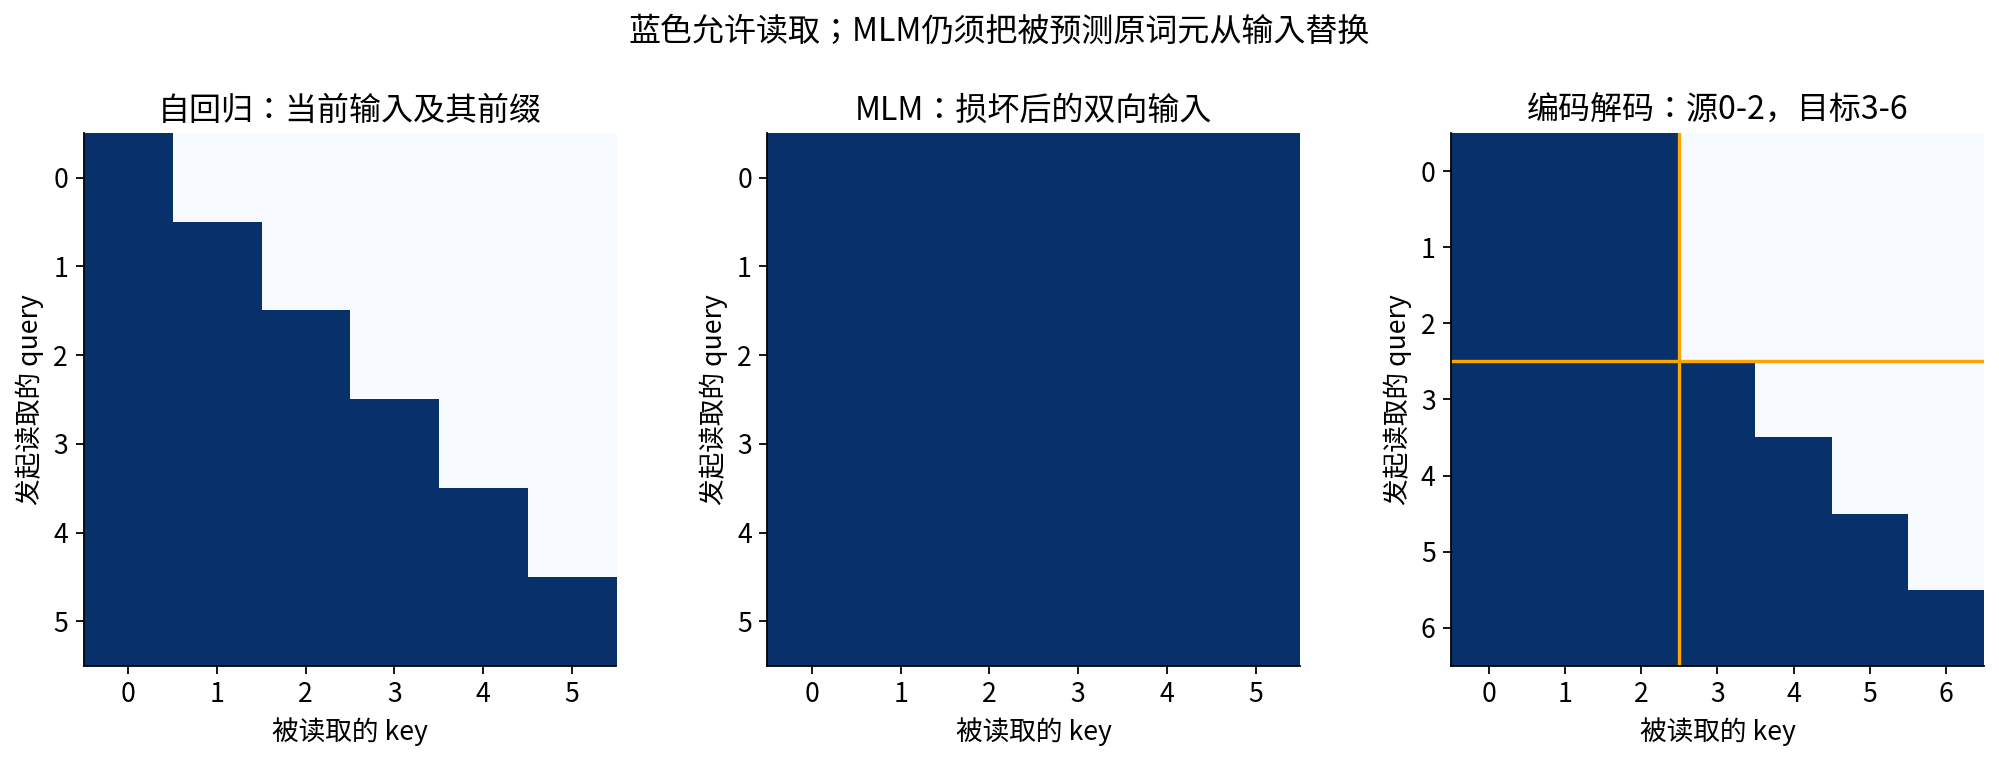

02_targets.png


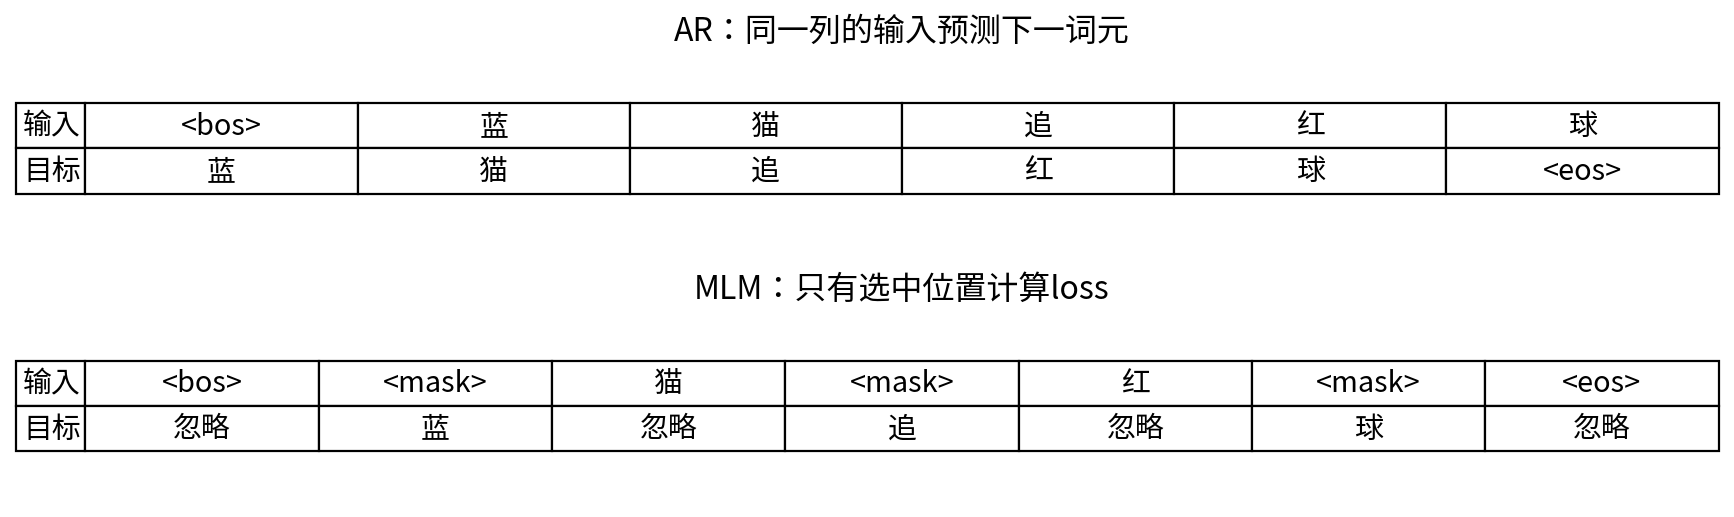

03_packing.png


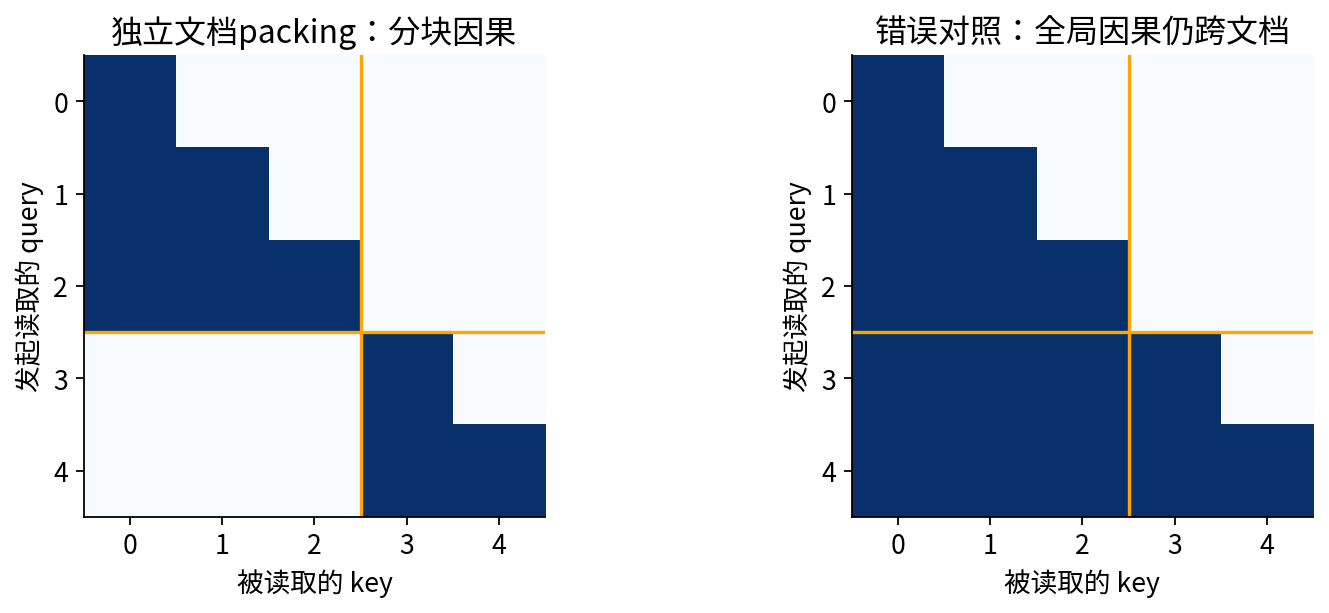

04_nll.png


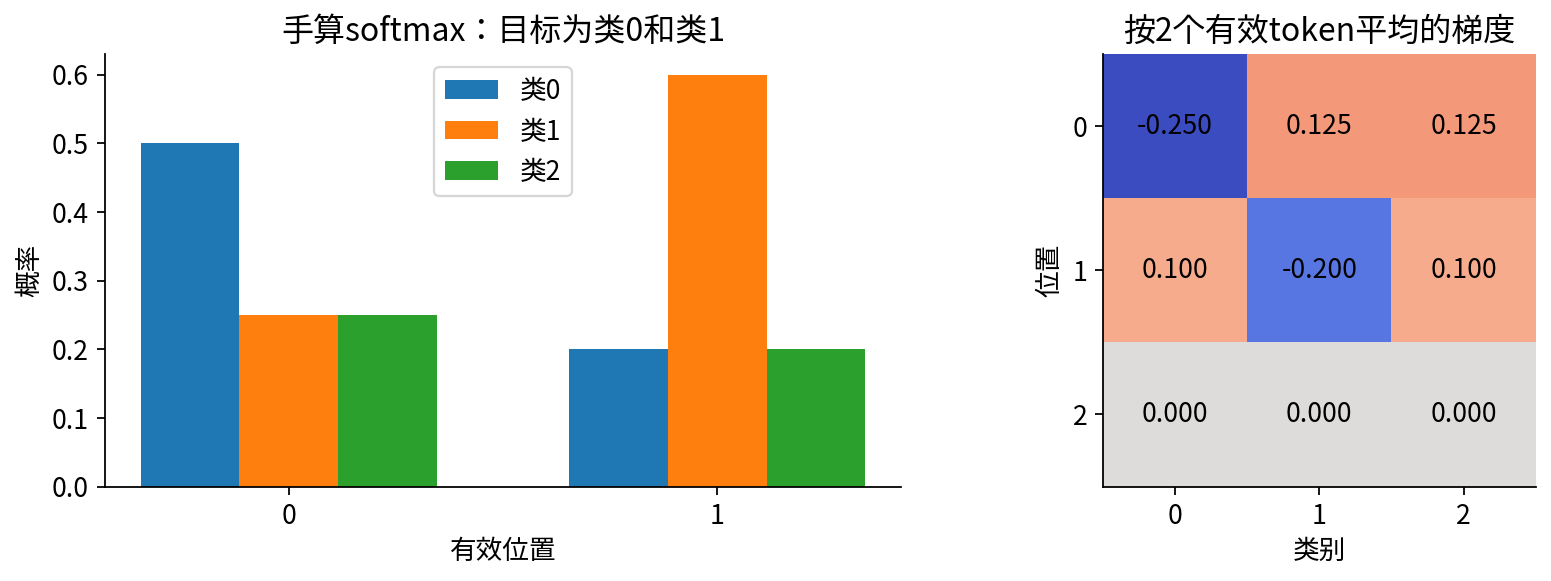

05_reduction.png


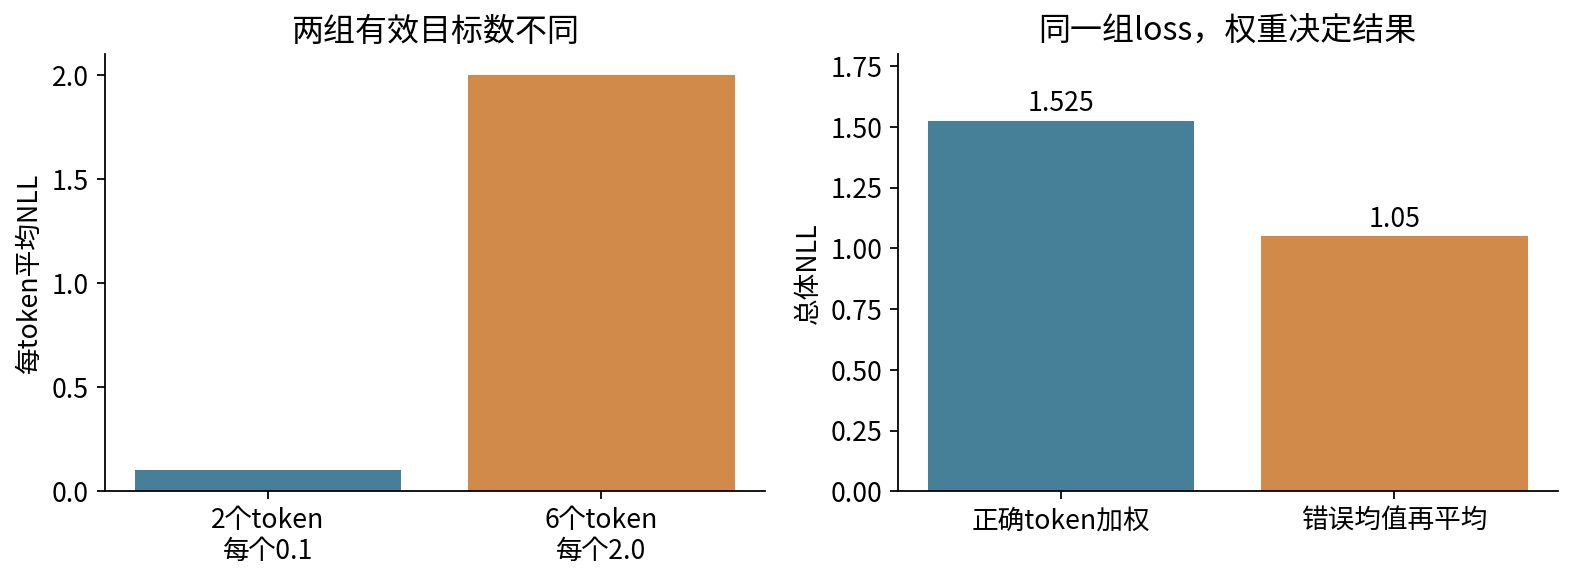

06_diagnostics.png


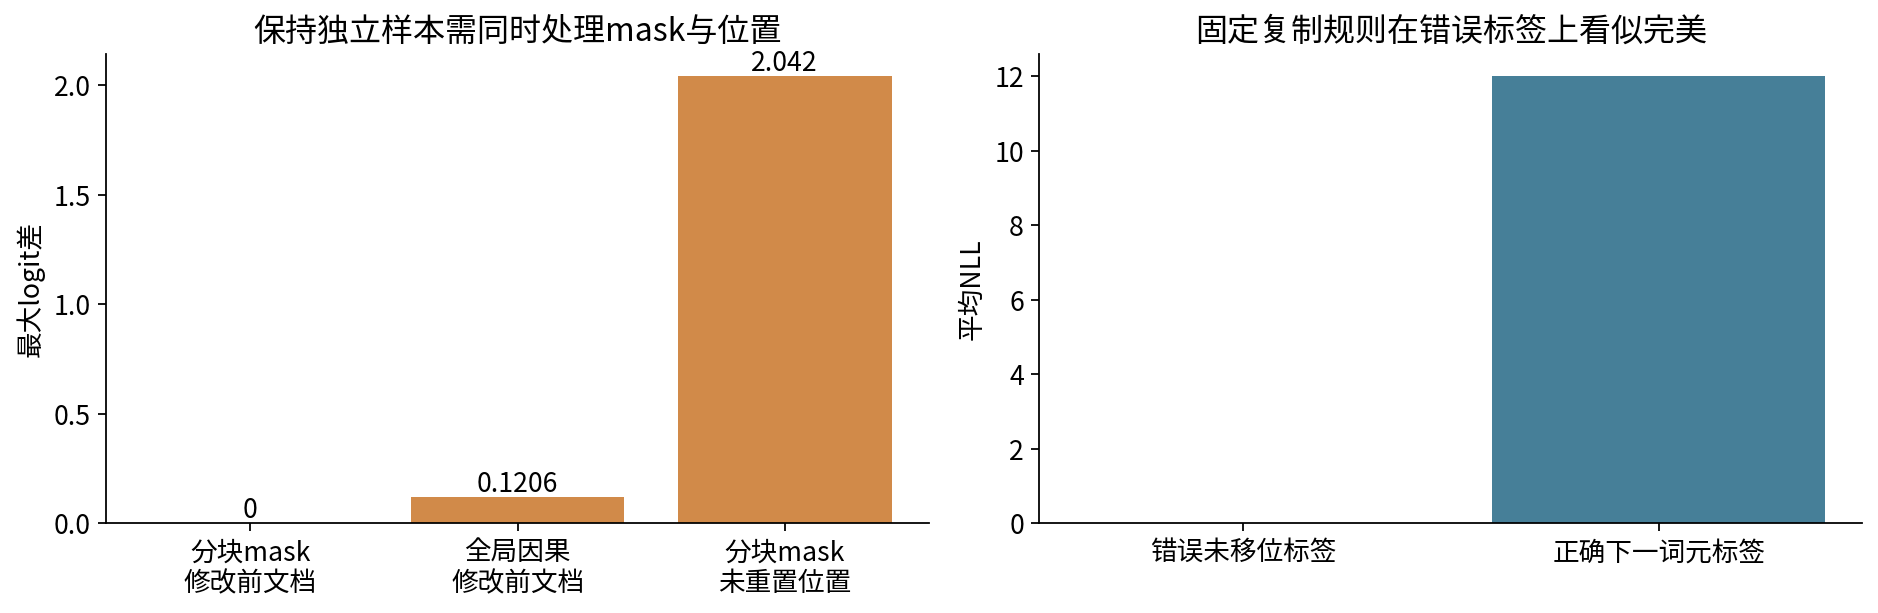

In [6]:
from make_figures import main as draw
from IPython.display import display,Image
folder=draw(REPLAY/"results.json",REPLAY/"figures")
for path in sorted(folder.glob("*.png")):
    print(path.name);display(Image(filename=str(path)))

## 6 结论
写出三种mask各自控制什么；解释EOS为什么不强制隔离文档；给出按有效token归约的分子与分母。保留所有失败对照，不把小语料未训练探针推广为真实中文质量结论。